## Лабораторна робота 6. **Unsupervised Learning**

Оцінювання даної роботи буде ураховувати якість Ваших висновків та візуалізацій. При наявності ЛИШЕ коду та візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.  

Більшість поставлених в цій лабораторній роботі задач в майбутньому буде ставитись Вами самойстійно!

Під час виконання Вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації.

Оформлення коментарів повинно проводитися в текстових комірках ноутбука з використанням синтаксису [LaTeX](https://en.wikibooks.org/wiki/LaTeX/Basics) для оформлення тексту та формул.

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.

## Кластерування  

В цій лабораторній роботі Ви будете вирішувати задачу класифікації БЕЗ вчителя.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy
from scipy.spatial import distance_matrix
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

import os
import warnings
warnings.filterwarnings('ignore')

**Завдання 0**

Для початку необхідно завантажити вибірку `Mall_Customers` і перейменувати атрибути `Annual Income (k$)` в `Income`,`Spending Score (1-100)` в `SpendingScore`

In [ ]:
customer_set = pd.read_csv('/content/sample_data/Mall_Customers.csv')
customer_set.rename(columns={
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'SpendingScore'
}, inplace=True)

**Завдання 1**

Підготовка даних до опрацювання

* подивитись які атрибути містить вибірка;
* вивести розмірність датасету;
* вивести основну статистичну інформацію по числовим змінним;  
* перевірити на наявність `NaN`.   

In [ ]:
print("Атрибути вибірки, які містить вибірка: \n")
print(customer_set.columns)

print("Розмірність:  \n")
print(customer_set.shape)

print("Основна статистична інформація по числовим змінним: \n")
print(customer_set.describe())

print("Наяість NaN:")
print(customer_set.isna().sum())

Атрибути вибірки, які містить вибірка: 

Index(['CustomerID', 'Gender', 'Age', 'Income', 'SpendingScore'], dtype='object')
Розмірність:  

(200, 5)
Основна статистична інформація по числовим змінним: 

       CustomerID         Age      Income  SpendingScore
count  200.000000  200.000000  200.000000     200.000000
mean   100.500000   38.850000   60.560000      50.200000
std     57.879185   13.969007   26.264721      25.823522
min      1.000000   18.000000   15.000000       1.000000
25%     50.750000   28.750000   41.500000      34.750000
50%    100.500000   36.000000   61.500000      50.000000
75%    150.250000   49.000000   78.000000      73.000000
max    200.000000   70.000000  137.000000      99.000000
Наяість NaN:
CustomerID       0
Gender           0
Age              0
Income           0
SpendingScore    0
dtype: int64


## EDA Mall Customers

**Завдання 2**

Як Ви могли помітити по статистичній аналітиці вибірки вона містить змінну `CustomerID`. Ця змінна не впливає на аналіз даних тому її можна видалити.

In [ ]:
customer_set.drop("CustomerID", axis=1, inplace=True)
print(customer_set.head())

   Gender  Age  Income  SpendingScore
0    Male   19      15             39
1    Male   21      15             81
2  Female   20      16              6
3  Female   23      16             77
4  Female   31      17             40


**Завдання 3**

Побудувати діаграми розподілу по змінним `Age` , `Income` та `SpendingScore`

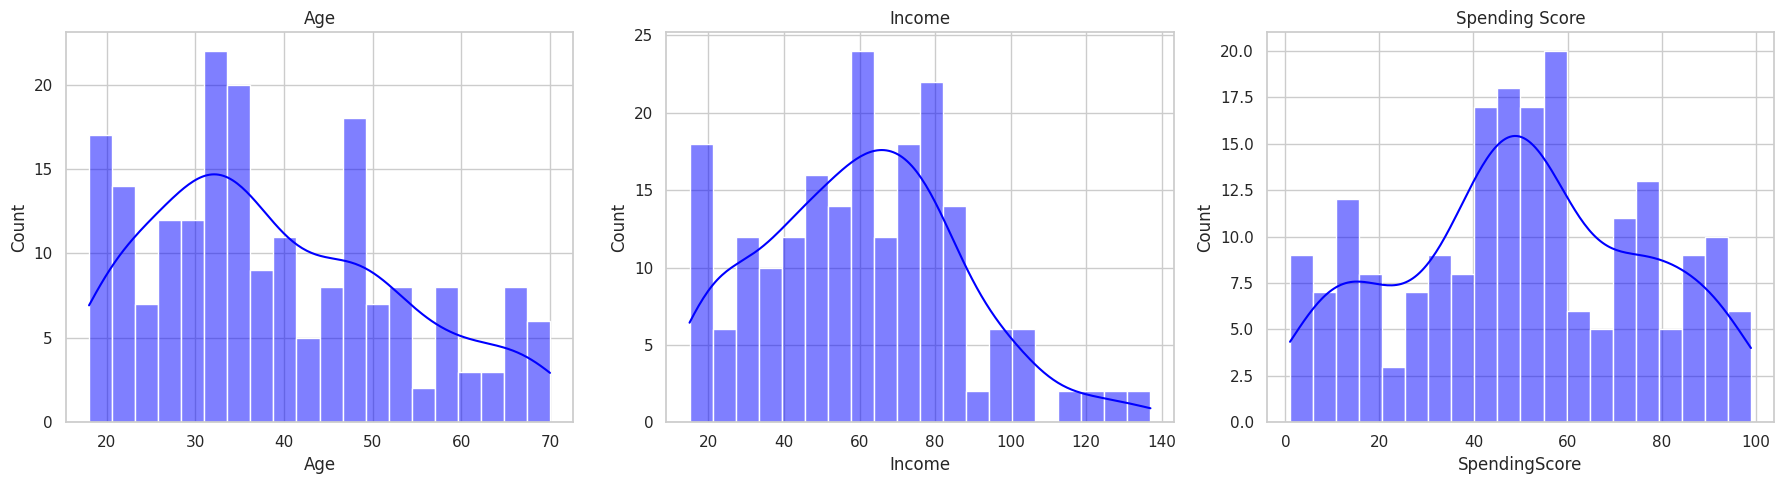

In [ ]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=customer_set, x='Age', kde=True, bins=20, color="blue", ax=axes[0])
axes[0].set_title("Age")

sns.histplot(data=customer_set, x='Income', kde=True, bins=20, color="blue", ax=axes[1])
axes[1].set_title("Income")

sns.histplot(data=customer_set, x='SpendingScore', kde=True, bins=20, color="blue", ax=axes[2])
axes[2].set_title("Spending Score")

plt.tight_layout()
plt.show()


**Завдання 4**

Давайте подивимось на ці змінні `Age` , `Income` та `SpendingScore` відносно змінної `Gender`.
* Побудуємо `pairplot` по всім змінним відностно змінної `Gender`:  

* Побудуємо `pairplot` використовуючи `sns.PairGrid` із заданими `(scatterplot)`, `(kdeplot)` та `(kdeplot, lw=1)` по відповідно правому верхньому куту, діагоналі і лівому нижньому кутут відносно змінної `Gender`:  


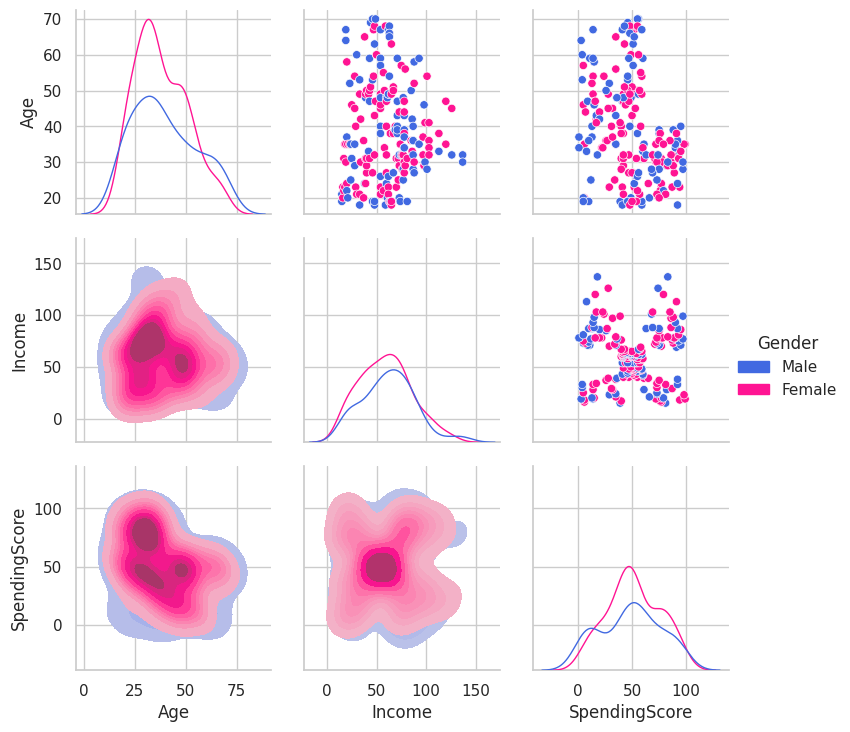

In [ ]:
pairplot_data = customer_set[['Gender', 'Age', 'Income', 'SpendingScore']]

g = sns.PairGrid(pairplot_data, hue="Gender", corner=False, palette={"Male": "royalblue", "Female": "deeppink"})
g.map_upper(sns.scatterplot)
g.map_diag(sns.kdeplot, lw=1)
g.map_lower(sns.kdeplot, fill=True)
g.add_legend()

plt.show()


**Висновки з 1-4 завдання (детальні)**

1. Отримали атрибути вибірки. Вивели розмірність датасету. Вивели основну інформацію. Перевірили, чи значення містять NaN

2. Видалилено змінну CustomerID.

3. Розподіл age, income та spendingscore. Age і Income мають помітні верхові показники, тоді як SpendingScore має інший розподіл.

4. Жінки трохи молодші та мають вищі значення SpendingScore, у той час як income розподілений майже одинаково.

**Завдання 5**

Проаналізувати змінну `Gender`:
* вивести співвідношення по статям;
* побудувати `countplot` по `Gender`;  
* побудувати `pie`по `Gender'.  

In [ ]:
gender_counts = customer_set['Gender'].value_counts()
print("Кількість за статтю:")
print(gender_counts)

gender_percent = customer_set['Gender'].value_counts(normalize=True) * 100
print("\nВідсоткове співвідношення:")
print(gender_percent.round(2))

Кількість за статтю:
Gender
Female    112
Male       88
Name: count, dtype: int64

Відсоткове співвідношення:
Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64


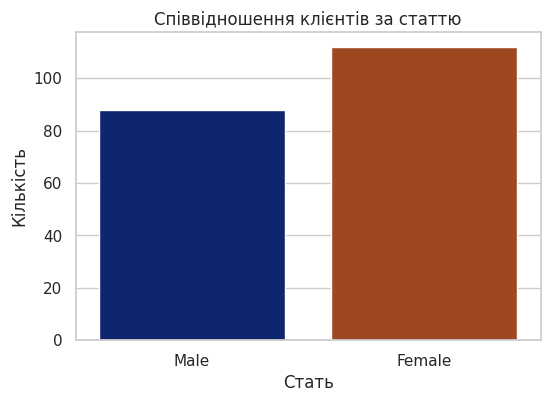

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", data=customer_set, palette="dark")
plt.title('Співвідношення клієнтів за статтю')
plt.ylabel('Кількість')
plt.xlabel('Стать')
plt.show()

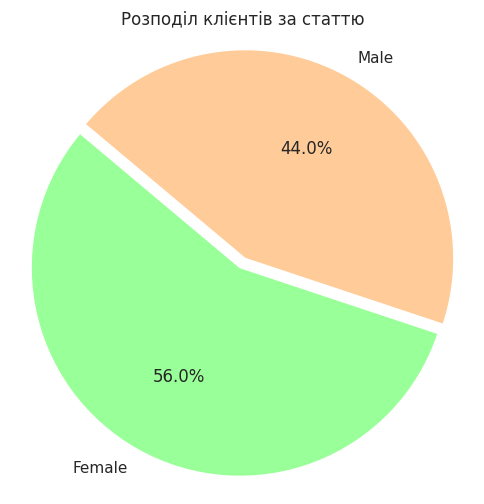

In [ ]:
labels = gender_counts.index
sizes = gender_counts.values
colors = ['#99ff99', '#ffcc99']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, explode=(0.05, 0))
plt.title('Розподіл клієнтів за статтю')
plt.axis('equal')
plt.show()


**Завдання 6**

Побудувати гістограми [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) змінних `Age` та `Income` відносно змінної `Gender` з різними параметрами:
*  подивитись на скільки змінюється візуалізація при різних значеннях параметра `multiple`, наприклад `dodge` та `layer`.

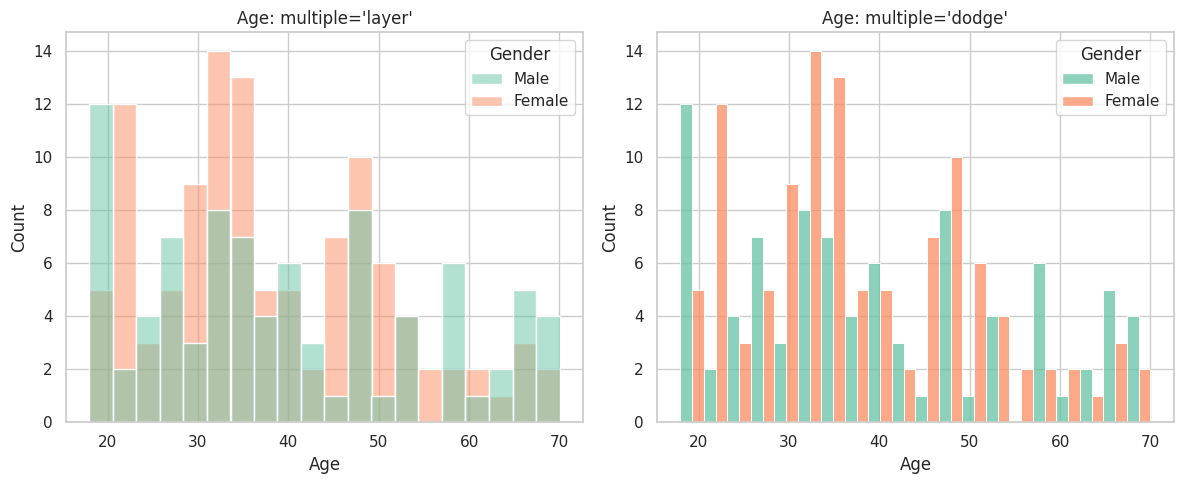

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=customer_set, x='Age', hue='Gender', multiple='layer', bins=20, palette='Set2')
plt.title("Age: multiple='layer'")

plt.subplot(1, 2, 2)
sns.histplot(data=customer_set, x='Age', hue='Gender', multiple='dodge', bins=20, palette='Set2')
plt.title("Age: multiple='dodge'")

plt.tight_layout()
plt.show()


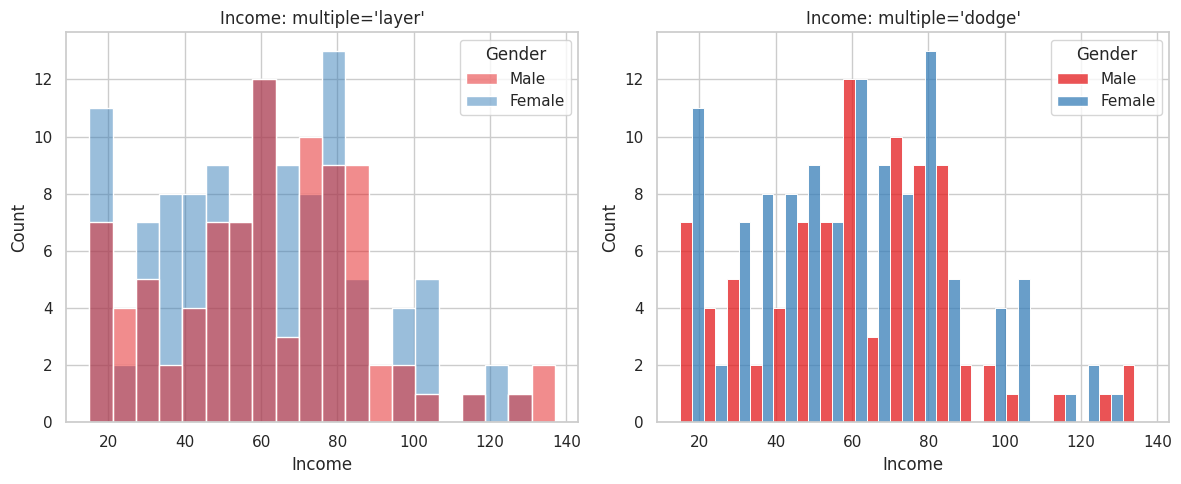

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=customer_set, x='Income', hue='Gender', multiple='layer', bins=20, palette='Set1')
plt.title("Income: multiple='layer'")

plt.subplot(1, 2, 2)
sns.histplot(data=customer_set, x='Income', hue='Gender', multiple='dodge', bins=20, palette='Set1')
plt.title("Income: multiple='dodge'")

plt.tight_layout()
plt.show()


**Завдання 7**

Побудувати гістограми [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) змінної `SpendingScore` відносно змінної `Gender` з різними параметрами:  
* подивитись на скільки змінюється візуалізація при різних значеннях параметра `multiple`, наприклад `dodge` та `layer`.



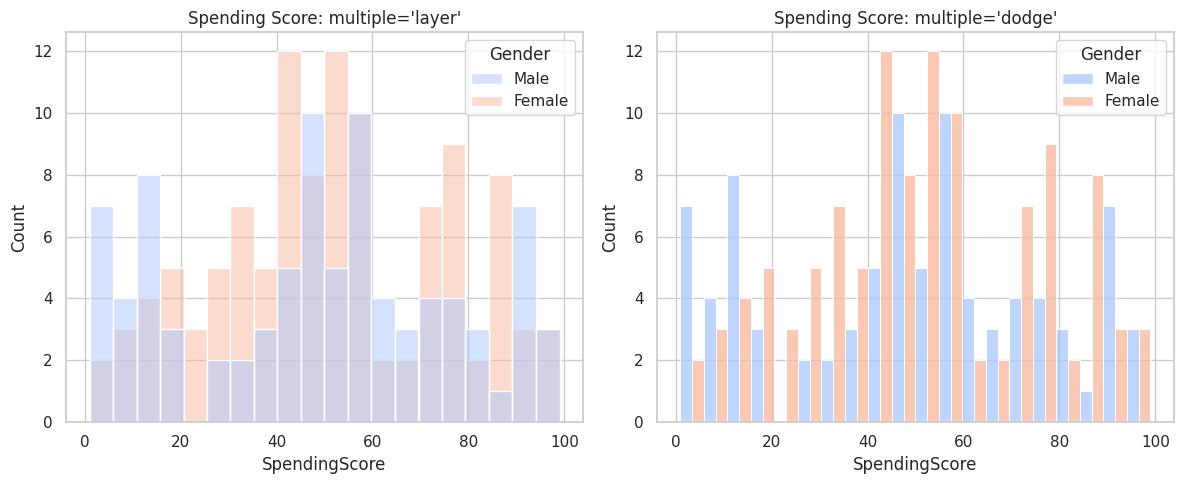

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=customer_set, x='SpendingScore', hue='Gender', multiple='layer', bins=20, palette='coolwarm')
plt.title("Spending Score: multiple='layer'")

plt.subplot(1, 2, 2)
sns.histplot(data=customer_set, x='SpendingScore', hue='Gender', multiple='dodge', bins=20, palette='coolwarm')
plt.title("Spending Score: multiple='dodge'")

plt.tight_layout()
plt.show()

**Завдання 8**

Побудувати `boxplot` по змінній `SpendingScore` і подивитись як відрізняються витрати відностно змінної `Gender`.

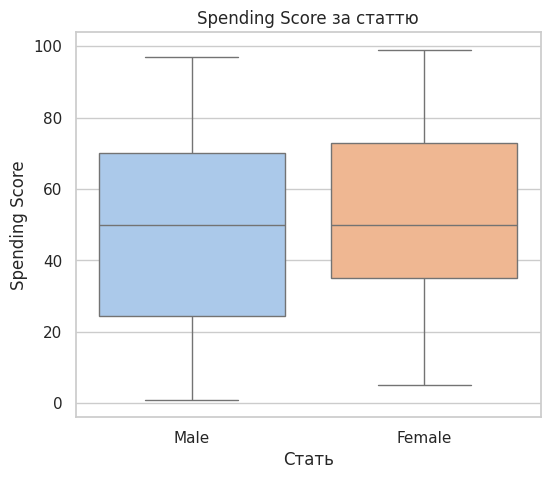

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=customer_set, x='Gender', y='SpendingScore', palette='pastel')

plt.title('Spending Score за статтю')
plt.xlabel('Стать')
plt.ylabel('Spending Score')
plt.show()

**Висновки з завдання 5 - 8(детальні)**

5. Співвідношення 56/44%.
6. Найбільший вік клієнтів: 30-40 років, розподіли між статями схожі, але в деяких чоловіки переважають.
7. Більше чоловіків знаходиться в низькій групі, у жінок більше клієнтів з високими витратами, але в обох статях є викиди.
8. Spending Score у чоловіків і жінок дуже схожий. Медіана у жінок вища.

## K-means Method ##

**Завдання 9**

Як Ви могли помітити, вибірка, з якою ми працюємо, не містить ключової зміної з вірними мітками. Тому перед початком кластерування необхідно визначити (підібрати) оптимальну кількість кластерів на яке буде проведено розбиття. Для цього необхідно:
1. видалити змінну `Gender`, тому що ... **Чому?**;  
2. задати мінімальну та максимальну кількість кластерів самостійно;  
3. На прикладі алгоритму [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), для ознайомлення з тим як працювати в умовах коли кількість кластерів невідома заздалегіть і немає вірних міток з позначками до якого кластеру відноситься спостереження пропонується використати метод [Elbow](https://coderoad.ru/19197715/Scikit-Learn-K-Means-Elbow-criterion) (додаткові джерела: [article_1](https://medium.com/analytics-vidhya/elbow-method-of-k-means-clustering-algorithm-a0c916adc540#:~:text=K%2Dmeans%20clustering%20is%20an,cluster%20with%20the%20nearest%20centroid.), [article_2](https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/))

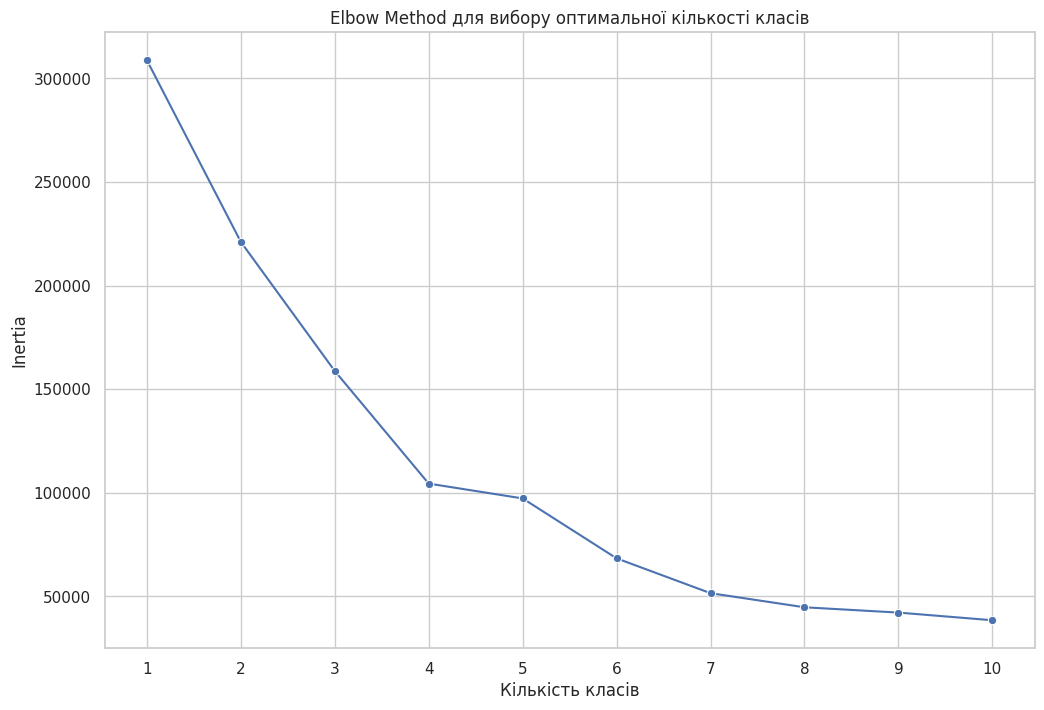

In [ ]:
X = customer_set.drop(['Gender'], axis=1)
clusters = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    clusters.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(x=list(range(1, 11)), y=clusters, marker='o', ax=ax)

ax.set_title('Elbow Method для вибору оптимальної кількості класів')
ax.set_xlabel('Кількість класів')
ax.set_ylabel('Inertia')

plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

**Висновки з завдання 9 (детальні)**

На графіку Elbow є помітний спад 3 та 4 кластерів. Отже, оптимальною кількістю кластерів для подальшого аналізу слід розглядати 3 або 4.

**Завдання 10**

Зробити двовимірну візуалізацію кластеризації методу К-середніх на вибраних Вами двох різних кількостях кластерів використовуючи змінні `Income` та `SpendingScore`.

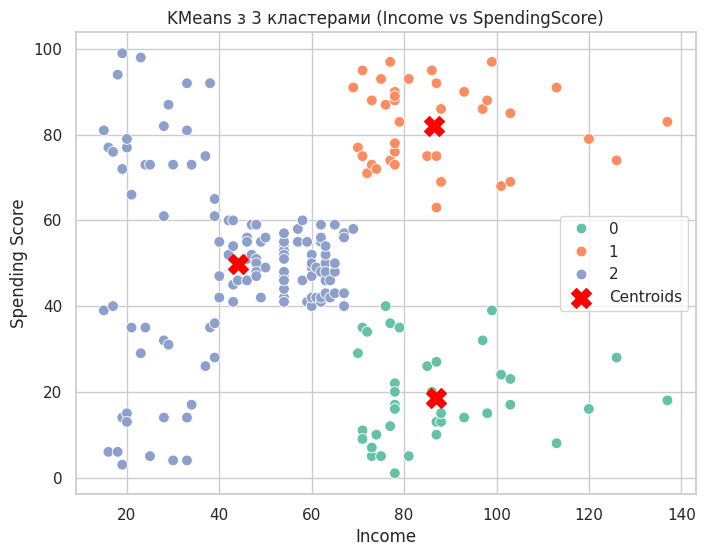

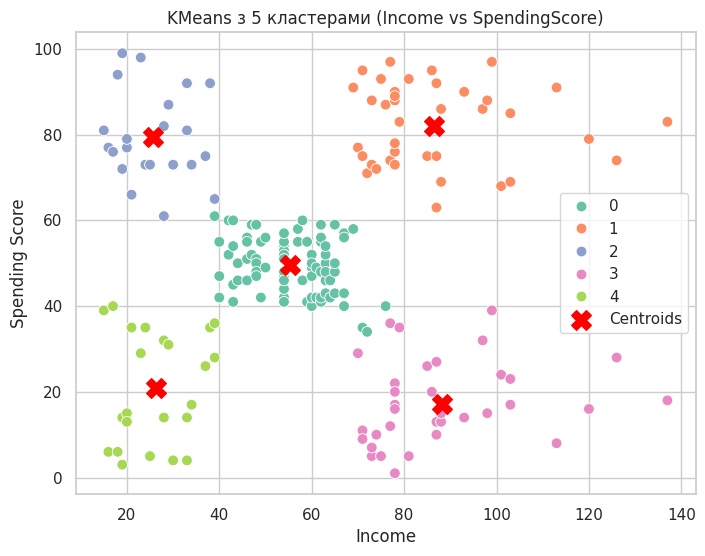

In [ ]:
X_2d = customer_set[['Income', 'SpendingScore']]

for k in [3, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_2d)
    centers = kmeans.cluster_centers_

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_2d['Income'], y=X_2d['SpendingScore'], hue=labels, palette='Set2', s=60)
    plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')

    plt.title(f'KMeans з {k} кластерами (Income vs SpendingScore)')
    plt.xlabel('Income')
    plt.ylabel('Spending Score')
    plt.legend()
    plt.grid(True)
    plt.show()

**Завдання 11**

Зробити візуалізацію кластеризації методу К-середніх на вибраних Вами двох різних кількостях кластерів використовуючи [scatter_3d](https://plotly.com/python/3d-scatter-plots/).

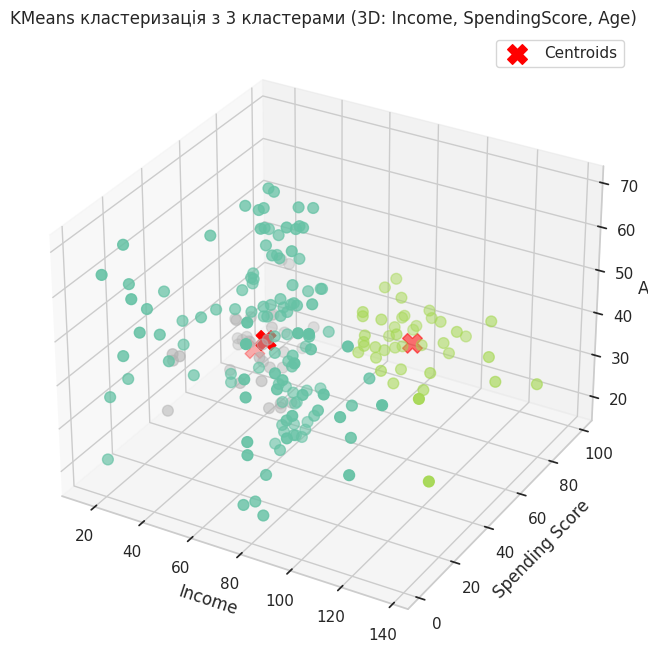

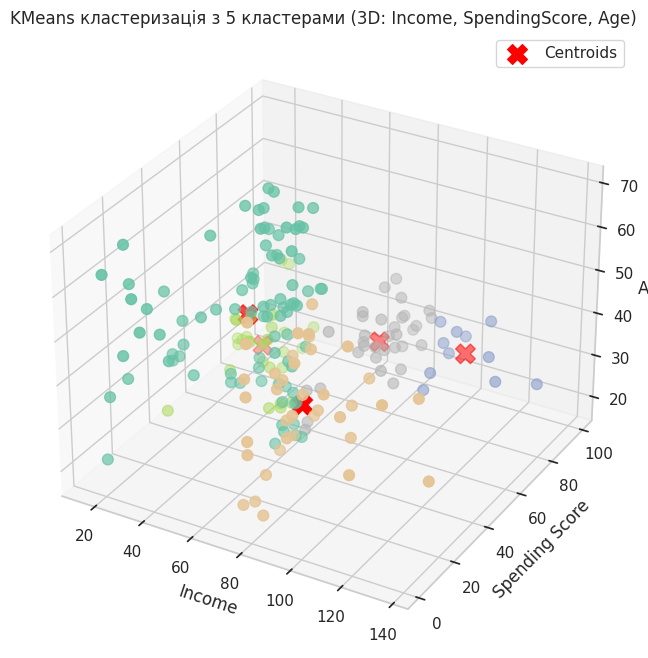

In [ ]:
X_3d = customer_set[['Income', 'SpendingScore', 'Age']]

for k in [3, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_3d)
    centers = kmeans.cluster_centers_

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(X_3d['Income'], X_3d['SpendingScore'], X_3d['Age'], c=labels, cmap='Set2', s=60)
    ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c='red', s=200, marker='X', label='Centroids')

    ax.set_title(f'KMeans кластеризація з {k} кластерами (3D: Income, SpendingScore, Age)')
    ax.set_xlabel('Income')
    ax.set_ylabel('Spending Score')
    ax.set_zlabel('Age')
    ax.legend()

    plt.show()

**Висновки з завдання 10 - 11 (детальні)**

Кластеризація видала результат з різними рівнями доходів і з різними результатами витрат.
Це дає змогу адаптовуватись під клієнтів.

## Agglomerative clustering ##

Розглянемо ще один підхід до кластеризації - [агломеративну ієрархічну кластеризацію](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

**Завдання 12**

Кластеризуйте датасет за допомогою [агломеративної ієрархічнуої кластеризації](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

Мінімально необхідні параметри, що треба налаштувати:  
* `n_clusters`: параметр, який відповідає за кільксіть кластерів на яку буде проведено розбиття вибірки;  
* `linkage`: параметр зв’язку. Цей параметр визначає, яку відстань використовувати між наборами спостережень.
* перевірте як працює цей метод з різними параметрами `linkage`  
* після кожної зміни параметрів - візуалізувати розбиття на кластери

Розрахувати матрицю відстаней для нашого набору даних:
* за допомогою методу [hierarchy.linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html) і матриці відстаней кластеризувати дані з різними значеннями параметра `method`
* за допомогою методу [hierarchy.dendrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html) візуалізувати отримані результати кластеризації у вигляді дендрограм


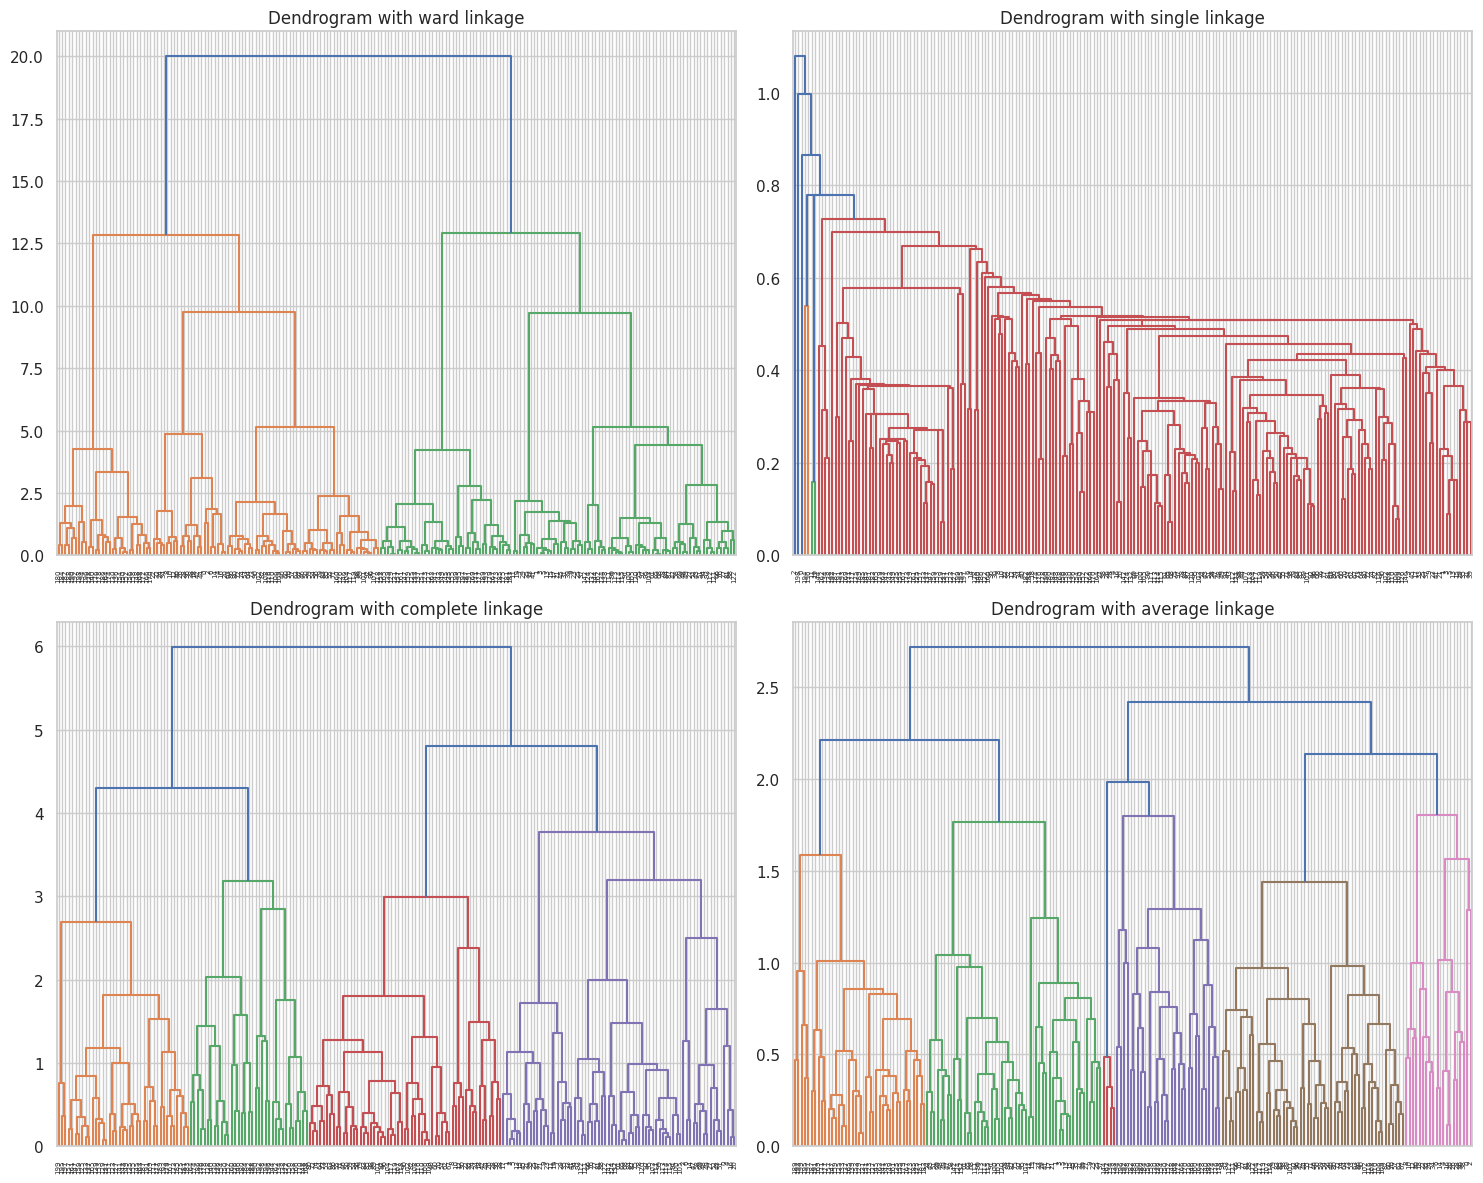

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_set[['Income', 'SpendingScore', 'Age']])

linkage_methods = ['ward', 'single', 'complete', 'average']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for i, method in enumerate(linkage_methods):
    Z = linkage(X_scaled, method=method)
    ax = axes[i//2, i%2]
    dendrogram(Z, ax=ax)
    ax.set_title(f'Dendrogram with {method} linkage')

plt.tight_layout()
plt.show()

**Висновки з завдання 12 (детальні)**

Метод "ward" мінімалізує. Метод "single" з'єднує найближчі точки, що може призводити до витягнутих кластерів. Метод "complete" враховує максимальну відстань між точками в двох кластерах. Метод "average" використовує середню відстань між усіма парами точок у двох кластерах.

**Завдання 13**

А тепер зробимо порівняльний аналіз отриманих результатів кластеризації розглянутими методами:  
* В фінальних візуалізаціях треба використовувати **однакову** (на вашу думку оптимальну) кількість кластерів!!!  

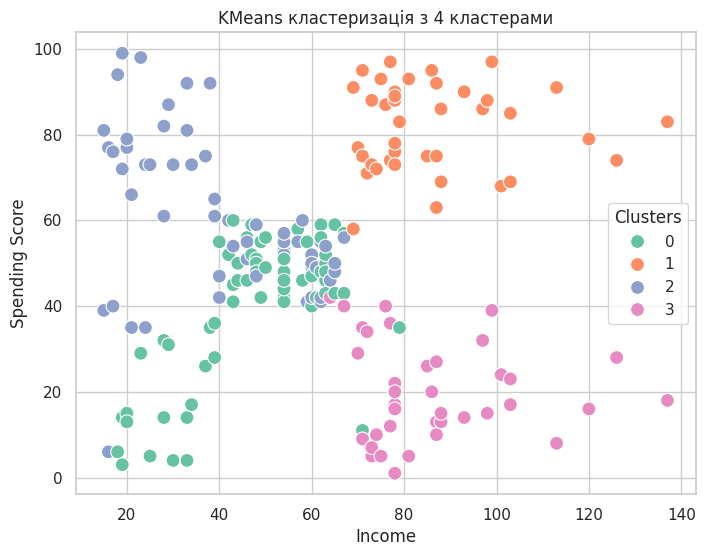

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=customer_set['Income'], y=customer_set['SpendingScore'], hue=kmeans_labels, palette='Set2', s=100)
plt.title(f'KMeans кластеризація з 4 кластерами')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.legend(title='Clusters')
plt.show()

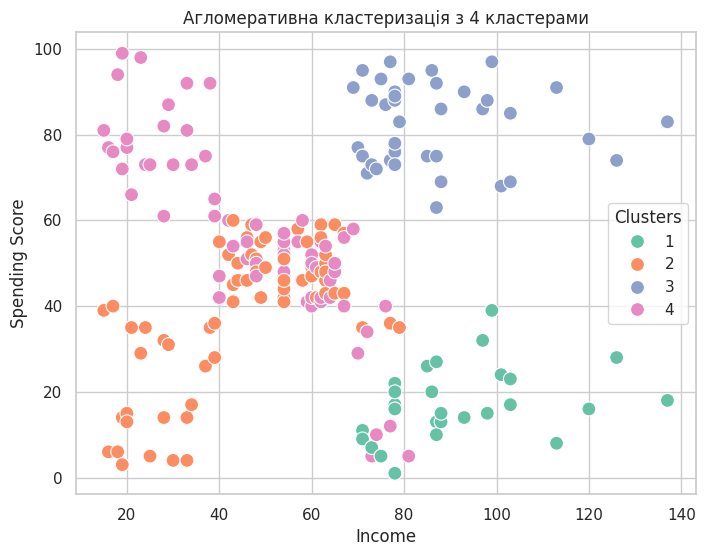

In [ ]:
Z = linkage(X_scaled, method='ward')
agg_labels = fcluster(Z, 4, criterion='maxclust')

plt.figure(figsize=(8, 6))
sns.scatterplot(x=customer_set['Income'], y=customer_set['SpendingScore'], hue=agg_labels, palette='Set2', s=100)
plt.title(f'Агломеративна кластеризація з 4 кластерами')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.legend(title='Clusters')
plt.show()

**Висновки з завдання 13 (детальні)**

Обидва методи поділили дані на чотири кластери, але по різному. KMeans краще відокремлює групу клієнтів із високим income і високим Spending Score. KMeans для чіткого розділення, а агломеративна — для виявлення однорідних структур.